# <a id="table-of-contents"></a>Table of Contents

1. [Intraday Mean Reversion](#section1)
2. [Moving Average](#section2)
3. [OBV](#section3)


In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.api as sms
import numpy as np
import warnings
import seaborn as sns
import statsmodels.stats.diagnostic as smd




from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.integrate import simps
from scipy.interpolate import interp1d
from scipy.integrate import quad


In [2]:
# Define the path to the Downloads folder and the file
downloads_folder = os.path.expanduser("~/Desktop")
file_name = "aaHistoricalData_1726248252859.csv" 
file_path = os.path.join(downloads_folder, file_name)

# Read the CSV file into a DataFrame
data = pd.read_csv(file_path)

In [19]:
# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Sort the DataFrame by date in ascending order
data = data.sort_values(by='Date', ascending=True)

print(data.head(3))

           Date  Close/Last     Volume    Open    High     Low  \
2509 2014-09-23      198.01  111103600  198.43  199.26  197.95   
2505 2014-09-29      197.54   95061580  196.20  197.89  196.05   
2501 2014-10-03      196.52  120932900  195.68  196.94  195.08   

      Original_Index  High_minus_Open  Open_minus_Low  day_change  \
2509            2509         0.004187        0.002422   -0.005724   
2505            2505         0.008584        0.000762   -0.001819   
2501            2501         0.006425        0.003060    0.011009   

      opening_gaps  net_Intraday_Movement_Around_Open_Ratio  \
2509     -0.003632                                 0.001766   
2505     -0.008635                                 0.007822   
2501      0.006629                                 0.003366   

      Intraday_Volatility  day_change_adjusted_for_openning_gap  Prev_Close  \
2509             0.006609                             -0.002092      199.15   
2505             0.009346                      

In [4]:
# Assuming 'data' is your existing DataFrame
data['Original_Index'] = data.index  # Add the Original_Index column to capture current index
print('''It will record the INDEX to make sure that future data manipulations don't force us to lose the order.''')

It will record the INDEX to make sure that future data manipulations don't force us to lose the order.


In [5]:
# Add new columns with the given calculations
data['High_minus_Open'] = (data['High'] - data['Open']) / ((data['Open'] + data['Close/Last']) / 2)
data['Open_minus_Low'] = (data['Open'] - data['Low']) / ((data['Open'] + data['Close/Last']) / 2)
data['day_change'] = (data['Close/Last'] - data['Close/Last'].shift(1)) / data['Close/Last'].shift(1)
data['opening_gaps'] = (data['Open'] - data['Close/Last'].shift(1)) / ((data['Open'] + data['Close/Last']) / 2)
data['net_Intraday_Movement_Around_Open_Ratio'] = ((data['High'] - data['Open']) / ((data['Open'] + data['Close/Last']) / 2)) - ((data['Open'] - data['Low']) / ((data['Open'] + data['Close/Last']) / 2))
data['Intraday_Volatility'] = ((data['High'] - data['Low']) / ((data['Open'] + data['Close/Last']) / 2))
data['day_change_adjusted_for_openning_gap'] = data['day_change'] - data['opening_gaps']

In [6]:
# Add new columns with the given calculations
data['Prev_Close'] = data['Close/Last'].shift(1)
data['opening_gaps'] = (data['Open'] - data['Close/Last'].shift(1)) / ((data['Open'] + data['Close/Last']) / 2)
data['net_Intraday_Movement_Around_Open_Ratio'] = ((data['High'] - data['Open']) / ((data['Open'] + data['Close/Last']) / 2)) - ((data['Open'] - data['Low']) / ((data['Open'] + data['Close/Last']) / 2))
data['Intraday_Volatility'] = ((data['High'] - data['Low']) / ((data['Open'] + data['Close/Last']) / 2))

In [7]:
# Calculate day change adjusted for opening gap
data['day_change_adjusted_for_openning_gap'] = data['day_change'] - data['opening_gaps']


# Shift 'High' and 'Low' columns by 1
data['High_shift'] = data['High'].shift(1)
data['Low_shift'] = data['Low'].shift(1)

# Define the opening gap with the condition
def calculate_opening_gaps(row):
    if row['Open'] > row['High_shift']:
        return (row['Open'] - row['High_shift']) / ((row['Open'] + row['Close/Last']) / 2)
    elif row['Open'] < row['Low_shift']:
        return (row['Open'] - row['Low_shift']) / ((row['Open'] + row['Close/Last']) / 2)
    else:
        return np.nan

# Apply the calculation function to each row
data['opening_gaps_2'] = data.apply(calculate_opening_gaps, axis=1)

data.dropna(inplace=True)

In [8]:
# Logistic regression preparation: Convert 'day_change' to binary and create a new column 'day_change_binary' (0 for Down, 1 for Up)
data['day_change_binary'] = data['day_change'].apply(lambda x: 1 if x > 0 else 0)

# Ensure all columns are numeric
data = data.apply(pd.to_numeric, errors='coerce')

END OF SETUP

# <a id="section4"></a> Opening Gaps and Intraday Volatility
[Back to Table of Contents](#table-of-contents)


                             OLS Regression Results                            
Dep. Variable:     Intraday_Volatility   R-squared:                       0.082
Model:                             OLS   Adj. R-squared:                  0.076
Method:                  Least Squares   F-statistic:                     12.51
Date:                 Sat, 11 Jan 2025   Prob (F-statistic):           0.000529
Time:                         15:39:59   Log-Likelihood:                 577.65
No. Observations:                  163   AIC:                            -1151.
Df Residuals:                      161   BIC:                            -1145.
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0058      0.002    

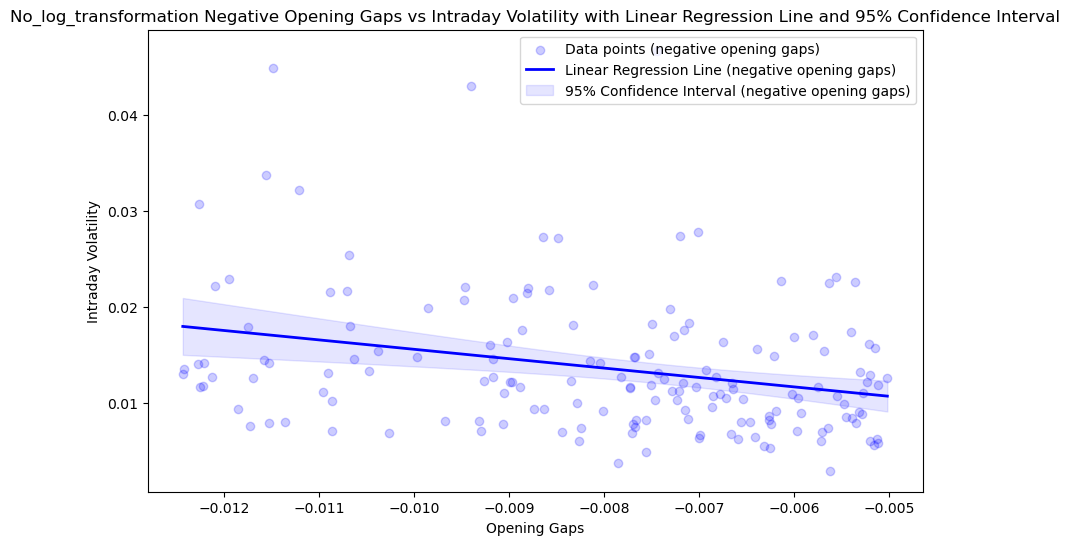

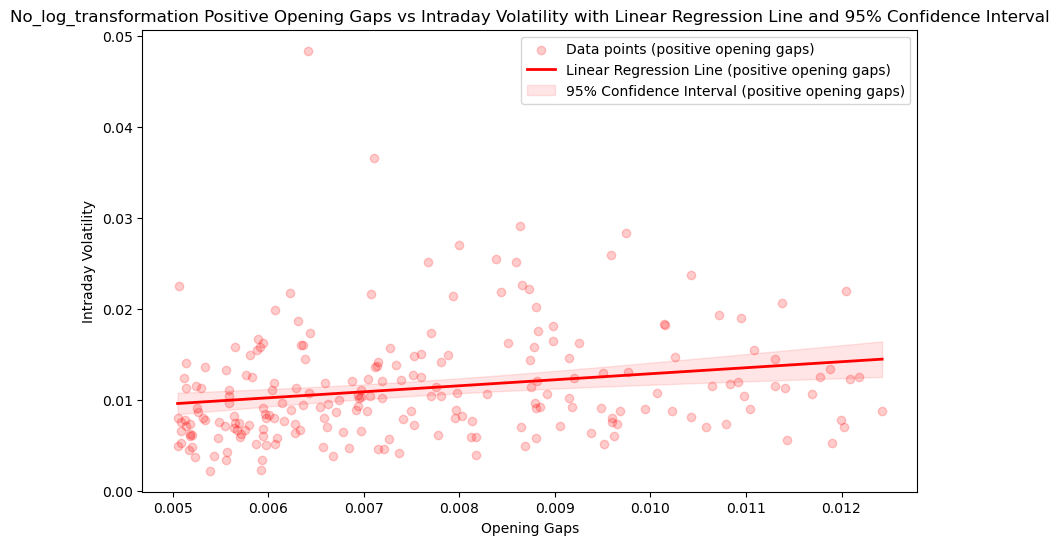


Address the heteroskedasticity at least in part by doing a log transformation



In [9]:
# Filter the DataFrame based on the specified criteria and intraday volatility
filtered_data_below = data.loc[(data['opening_gaps'] > -0.0125) & (data['opening_gaps'] < -0.005) & (data['Intraday_Volatility'] <= 0.05)].copy()
filtered_data_above = data.loc[(data['opening_gaps'] > 0.005) & (data['opening_gaps'] < 0.0125) & (data['Intraday_Volatility'] <= 0.05)].copy()

# First regression (below -0.005 and greater than -0.0125)
X_below = filtered_data_below['opening_gaps']
X_below = sm.add_constant(X_below)  # Adds a constant term to the predictor

y_below = filtered_data_below['Intraday_Volatility']

# Fit the model with RBSE
model_below = sm.OLS(y_below, X_below).fit(cov_type='HC3')

# Print the OLS results
print(model_below.summary())

# Predict values and get confidence intervals
predictions_below = model_below.get_prediction(X_below)
predictions_below_summary = predictions_below.summary_frame(alpha=0.05)
predicted_mean_below = predictions_below_summary['mean']
conf_int_below_lower = predictions_below_summary['mean_ci_lower']
conf_int_below_upper = predictions_below_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_below = np.argsort(filtered_data_below['opening_gaps'])
sorted_opening_gaps_below = filtered_data_below['opening_gaps'].values[sorted_idx_below]
sorted_conf_int_below_lower = conf_int_below_lower.values[sorted_idx_below]
sorted_conf_int_below_upper = conf_int_below_upper.values[sorted_idx_below]
sorted_predicted_mean_below = predicted_mean_below.values[sorted_idx_below]

# Second regression (greater than 0.005 and less than 0.0125)
X_above = filtered_data_above['opening_gaps']
X_above = sm.add_constant(X_above)  # Adds a constant term to the predictor

y_above = filtered_data_above['Intraday_Volatility']

# Fit the model with RBSE
model_above = sm.OLS(y_above, X_above).fit(cov_type='HC3')

# Print the OLS results
print(model_above.summary())

# Predict values and get confidence intervals
predictions_above = model_above.get_prediction(X_above)
predictions_above_summary = predictions_above.summary_frame(alpha=0.05)
predicted_mean_above = predictions_above_summary['mean']
conf_int_above_lower = predictions_above_summary['mean_ci_lower']
conf_int_above_upper = predictions_above_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_above = np.argsort(filtered_data_above['opening_gaps'])
sorted_opening_gaps_above = filtered_data_above['opening_gaps'].values[sorted_idx_above]
sorted_conf_int_above_lower = conf_int_above_lower.values[sorted_idx_above]
sorted_conf_int_above_upper = conf_int_above_upper.values[sorted_idx_above]
sorted_predicted_mean_above = predicted_mean_above.values[sorted_idx_above]

# Create the scatter plot for negative opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the first regression
plt.scatter(filtered_data_below['opening_gaps'], filtered_data_below['Intraday_Volatility'], 
                             color='blue', alpha=0.2, label='Data points (negative opening gaps)')

# Plot the linear regression line for the first regression
plt.plot(sorted_opening_gaps_below, sorted_predicted_mean_below, color='blue', linewidth=2, label='Linear Regression Line (negative opening gaps)')

# Plot the confidence intervals for the first regression
plt.fill_between(sorted_opening_gaps_below, sorted_conf_int_below_lower, sorted_conf_int_below_upper, color='blue', alpha=0.1, label='95% Confidence Interval (negative opening gaps)')

# Add labels and title
plt.xlabel('Opening Gaps')
plt.ylabel('Intraday Volatility')
plt.title('No_log_transformation Negative Opening Gaps vs Intraday Volatility with Linear Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Create the scatter plot for positive opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the second regression
plt.scatter(filtered_data_above['opening_gaps'], filtered_data_above['Intraday_Volatility'], 
                             color='red', alpha=0.2, label='Data points (positive opening gaps)')

# Plot the linear regression line for the second regression
plt.plot(sorted_opening_gaps_above, sorted_predicted_mean_above, color='red', linewidth=2, label='Linear Regression Line (positive opening gaps)')

# Plot the confidence intervals for the second regression
plt.fill_between(sorted_opening_gaps_above, sorted_conf_int_above_lower, sorted_conf_int_above_upper, color='red', alpha=0.1, label='95% Confidence Interval (positive opening gaps)')

# Add labels and title
plt.xlabel('Opening Gaps')
plt.ylabel('Intraday Volatility')
plt.title('No_log_transformation Positive Opening Gaps vs Intraday Volatility with Linear Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

print('''
Address the heteroskedasticity at least in part by doing a log transformation
''')


In [10]:
# Perform the Breusch-Pagan test for the first regression (negative opening gaps)
test_below = sms.het_breuschpagan(model_below.resid, model_below.model.exog)

print('Breusch-Pagan Test for Negative Opening Gaps:')
print(f'Lagrange  multiplier statistic: {test_below[0]}')
print(f'p-value: {test_below[1]}')
print(f'F-statistic: {test_below[2]}')
print(f'F-test p-value: {test_below[3]}')

Breusch-Pagan Test for Negative Opening Gaps:
Lagrange  multiplier statistic: 3.173871947702026
p-value: 0.07482486376553107
F-statistic: 3.197183025123524
F-test p-value: 0.07564594456125835


In [11]:
# Perform the Breusch-Pagan test for the second regression (positive opening gaps)
test_above = sms.het_breuschpagan(model_above.resid, model_above.model.exog)

print('Breusch-Pagan Test for Positive Opening Gaps:')
print(f'Lagrange BP multiplier statistic: {test_above[0]}')
print(f'p-value: {test_above[1]}')
print(f'F-statistic: {test_above[2]}')
print(f'F-test p-value: {test_above[3]}')

Breusch-Pagan Test for Positive Opening Gaps:
Lagrange BP multiplier statistic: 0.04639286568695278
p-value: 0.8294632413030765
F-statistic: 0.045980808641967706
F-test p-value: 0.8304111312673053


In [12]:
# Dictionary to store test results for different lags
lag_stats_above = {}

# Loop through lags from 1 to 10
for lag in range(1, 11):
    bg_test_above = smd.acorr_breusch_godfrey(model_above, nlags=lag)
    lag_stats_above[lag] = bg_test_above  # Store the test results

# Sort the lag statistics in descending order and get the top 3
sorted_lag_stats_above = sorted(lag_stats_above.items(), key=lambda item: item[1][0], reverse=True)[:3]

# Print the results
print('Top 3 Lags with Highest Lagrange Multiplier Statistics for Positive Opening Gaps:')
for lag, result in sorted_lag_stats_above:
    lm_statistic = result[0]
    p_value = result[1]
    f_statistic = result[2]
    f_test_p_value = result[3]
    print(f'Lag: {lag}')
    print(f'Lagrange multiplier statistic: {lm_statistic}')
    print(f'p-value: {p_value}')
    print(f'F-statistic: {f_statistic}')
    print(f'F-test p-value: {f_test_p_value}')
    print('---')

print('''
the godfrey test will use all the features and the lagged residuals (# of lagged time periods specified) in order to explain the residuals. Increasing the
# of accepted lags will spike the LAgrange multiplier essentially giving you an overfit model. The code above balances optimizing the p-value with the Lagrange
Multiplier.

When increasing the number of lagged values increases the p-value by "significant_rise" the loop stops

''')

Top 3 Lags with Highest Lagrange Multiplier Statistics for Positive Opening Gaps:
Lag: 10
Lagrange multiplier statistic: 24.751234665031838
p-value: 0.005837515607371438
F-statistic: 2.6367679209106947
F-test p-value: 0.004812053469407573
---
Lag: 9
Lagrange multiplier statistic: 24.74651701837571
p-value: 0.0032647547677603444
F-statistic: 2.9431952180889325
F-test p-value: 0.002606047881212647
---
Lag: 8
Lagrange multiplier statistic: 24.608024799561203
p-value: 0.0018108977068014378
F-statistic: 3.305973289465121
F-test p-value: 0.0014037849754929574
---

the godfrey test will use all the features and the lagged residuals (# of lagged time periods specified) in order to explain the residuals. Increasing the
# of accepted lags will spike the LAgrange multiplier essentially giving you an overfit model. The code above balances optimizing the p-value with the Lagrange
Multiplier.

When increasing the number of lagged values increases the p-value by "significant_rise" the loop stops




In [13]:
# Initialize variables
previous_p_value_above = float('inf')  # Set initial previous p-value to infinity
significant_rise = 0.02  # Define a threshold for significant rise in p-value

# List to store test results for different lags for positive opening gaps
lag_results_above = []

# Loop through lags until we see a significant rise in p-value
for lag in range(1, 21):  # Example: increase lags up to 20
    bg_test_above = smd.acorr_breusch_godfrey(model_above, nlags=lag)
    lag_results_above.append((lag, bg_test_above))  # Store the test results

    # Extract current p-value
    current_p_value_above = bg_test_above[1]

    # Check if p-value starts to rise significantly
    if current_p_value_above > previous_p_value_above + significant_rise:
        break

    # Update previous p-value
    previous_p_value_above = current_p_value_above

# Print the last 3 lag results for positive opening gaps
print('Results for the Last 3 Lags Tested for Positive Opening Gaps:')
for lag, bg_test in lag_results_above[-3:]:
    print(f'Lag: {lag}')
    print(f'Lagrange multiplier statistic: {bg_test[0]}')
    print(f'p-value: {bg_test[1]}')
    print(f'F-statistic: {bg_test[2]}')
    print(f'F-test p-value: {bg_test[3]}')
    print('---')

    
print('''
the godfrey test will use all the features and the lagged residuals (# of lagged time periods specified) in order to explain the residuals. Increasing the
# of accepted lags will spike the LAgrange multiplier essentially giving you an overfit model. The code above balances optimizing the p-value with the Lagrange
Multiplier.

When increasing the number of lagged values increases the p-value by "significant_rise" the loop stops

''')

Results for the Last 3 Lags Tested for Positive Opening Gaps:
Lag: 18
Lagrange multiplier statistic: 28.164469368968096
p-value: 0.059596041698775984
F-statistic: 1.6312856513842706
F-test p-value: 0.055220016928226125
---
Lag: 19
Lagrange multiplier statistic: 28.471658585047592
p-value: 0.07476262923712308
F-statistic: 1.5569662367808146
F-test p-value: 0.07028183606146912
---
Lag: 20
Lagrange multiplier statistic: 28.48162662291215
p-value: 0.09847948129804837
F-statistic: 1.4722770384627946
F-test p-value: 0.09438393482624406
---

the godfrey test will use all the features and the lagged residuals (# of lagged time periods specified) in order to explain the residuals. Increasing the
# of accepted lags will spike the LAgrange multiplier essentially giving you an overfit model. The code above balances optimizing the p-value with the Lagrange
Multiplier.

When increasing the number of lagged values increases the p-value by "significant_rise" the loop stops




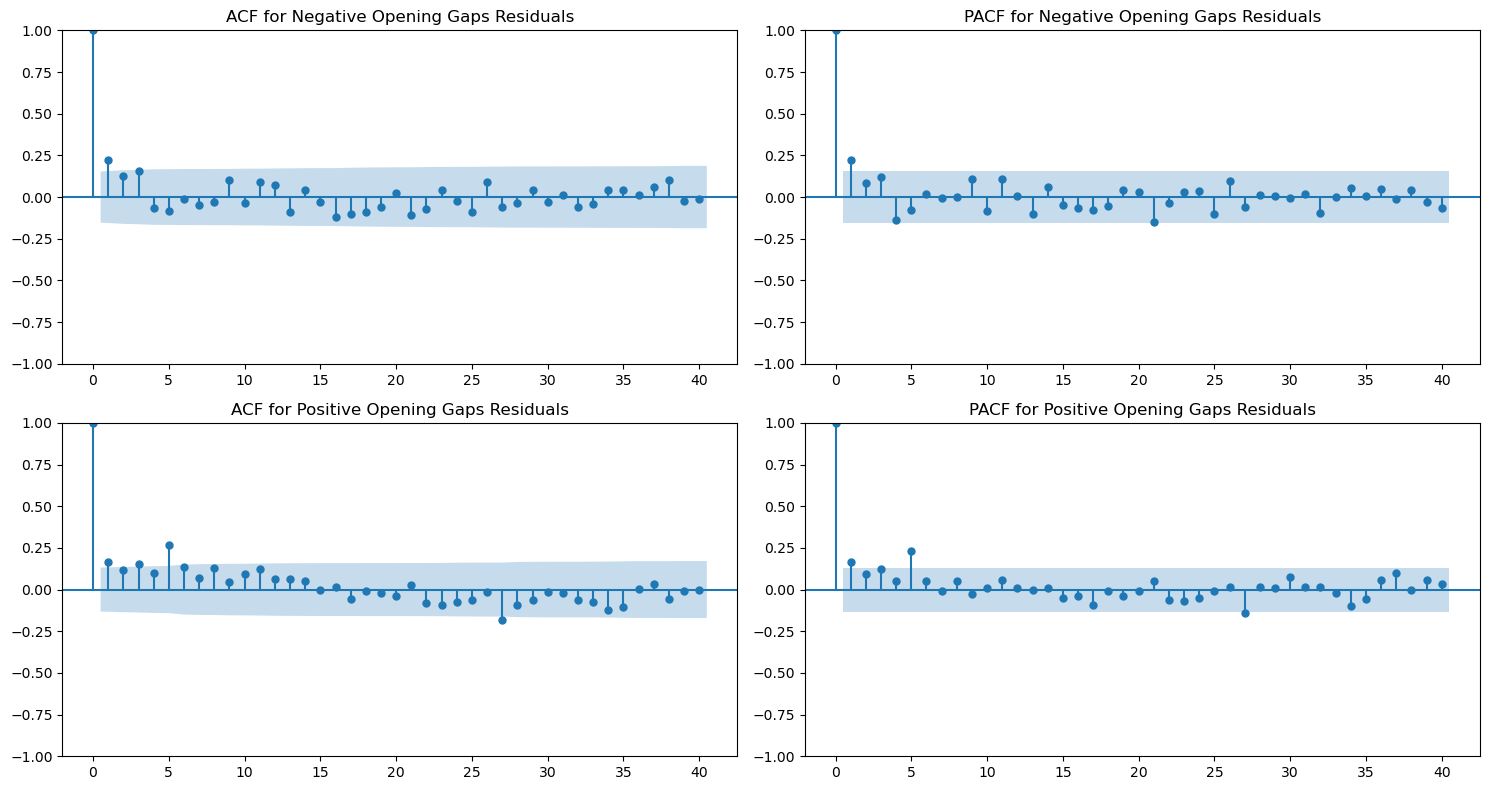

In [14]:
# Get the residuals for both regressions
residuals_below = model_below.resid
residuals_above = model_above.resid

# Plot ACF and PACF for negative opening gaps
plt.figure(figsize=(15, 8))

# ACF for negative opening gaps
plt.subplot(2, 2, 1)
sm.graphics.tsa.plot_acf(residuals_below, lags=40, ax=plt.gca())
plt.title('ACF for Negative Opening Gaps Residuals')

# PACF for negative opening gaps
plt.subplot(2, 2, 2)
sm.graphics.tsa.plot_pacf(residuals_below, lags=40, ax=plt.gca())
plt.title('PACF for Negative Opening Gaps Residuals')

# Plot ACF and PACF for positive opening gaps
# ACF for positive opening gaps
plt.subplot(2, 2, 3)
sm.graphics.tsa.plot_acf(residuals_above, lags=40, ax=plt.gca())
plt.title('ACF for Positive Opening Gaps Residuals')

# PACF for positive opening gaps
plt.subplot(2, 2, 4)
sm.graphics.tsa.plot_pacf(residuals_above, lags=40, ax=plt.gca())
plt.title('PACF for Positive Opening Gaps Residuals')

# Adjust layout and show plots
plt.tight_layout()
plt.show()


                             OLS Regression Results                            
Dep. Variable:     Intraday_Volatility   R-squared:                       0.082
Model:                             OLS   Adj. R-squared:                  0.076
Method:                  Least Squares   F-statistic:                     13.60
Date:                 Sat, 11 Jan 2025   Prob (F-statistic):           0.000309
Time:                         15:40:00   Log-Likelihood:                 577.70
No. Observations:                  163   AIC:                            -1151.
Df Residuals:                      161   BIC:                            -1145.
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

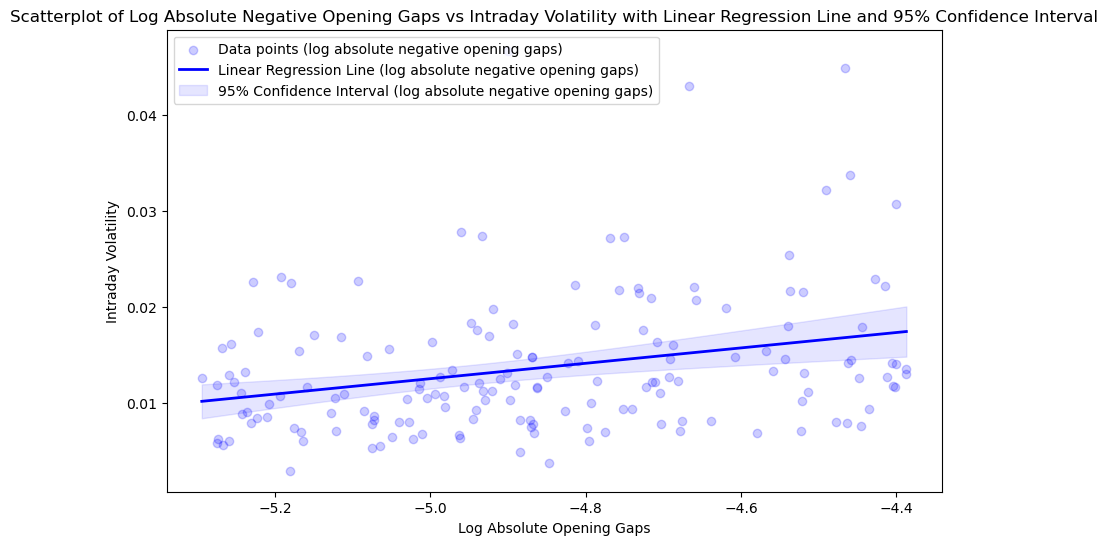

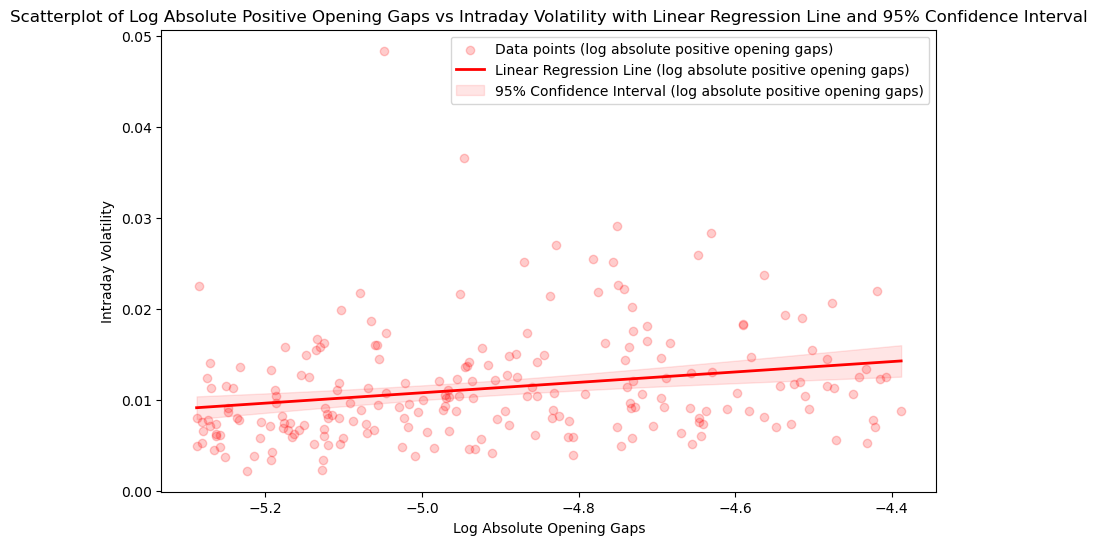

Negative Opening Gaps - Lagrange multiplier statistic: 3.2506855156666195
Negative Opening Gaps - p-value: 0.07139359290914153
Positive Opening Gaps - Lagrange multiplier statistic: 0.15343892186648
Positive Opening Gaps - p-value: 0.6952704273718949
 

Yes, the fact that your data is already log-transformed and you're still seeing significant heteroskedasticity in the Breusch-Pagan test results does indicate a 
serious issue. The purpose of log transformation is often to stabilize variance and address heteroskedasticity, so the persistence of heteroskedasticity even after
transformation suggests that the variance in your data is quite problematic.




In [15]:
# Filter the DataFrame based on the specified criteria and intraday volatility
filtered_data_below = data.loc[(data['opening_gaps'] > -0.0125) & (data['opening_gaps'] < -0.005) & (data['Intraday_Volatility'] <= 0.05)].copy()
filtered_data_above = data.loc[(data['opening_gaps'] > 0.005) & (data['opening_gaps'] < 0.0125) & (data['Intraday_Volatility'] <= 0.05)].copy()

# Apply log transformation using the absolute values
filtered_data_below['log_abs_opening_gaps'] = np.log(np.abs(filtered_data_below['opening_gaps']))
filtered_data_above['log_abs_opening_gaps'] = np.log(filtered_data_above['opening_gaps'])

# First regression (below -0.005 and greater than -0.02)
X_below = filtered_data_below['log_abs_opening_gaps']
X_below = sm.add_constant(X_below)  # Adds a constant term to the predictor

y_below = filtered_data_below['Intraday_Volatility']

# Fit the model with RBSE
model_below = sm.OLS(y_below, X_below).fit(cov_type='HC3')

# Print the OLS results
print(model_below.summary())

# Predict values and get confidence intervals
predictions_below = model_below.get_prediction(X_below)
predictions_below_summary = predictions_below.summary_frame(alpha=0.05)
predicted_mean_below = predictions_below_summary['mean']
conf_int_below_lower = predictions_below_summary['mean_ci_lower']
conf_int_below_upper = predictions_below_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_below = np.argsort(filtered_data_below['log_abs_opening_gaps'])
sorted_log_abs_opening_gaps_below = filtered_data_below['log_abs_opening_gaps'].values[sorted_idx_below]
sorted_conf_int_below_lower = conf_int_below_lower.values[sorted_idx_below]
sorted_conf_int_below_upper = conf_int_below_upper.values[sorted_idx_below]
sorted_predicted_mean_below = predicted_mean_below.values[sorted_idx_below]

# Second regression (greater than 0.005 and less than 0.02)
X_above = filtered_data_above['log_abs_opening_gaps']
X_above = sm.add_constant(X_above)  # Adds a constant term to the predictor

y_above = filtered_data_above['Intraday_Volatility']

# Fit the model with RBSE
model_above = sm.OLS(y_above, X_above).fit(cov_type='HC3')

# Print the OLS results
print(model_above.summary())

# Predict values and get confidence intervals
predictions_above = model_above.get_prediction(X_above)
predictions_above_summary = predictions_above.summary_frame(alpha=0.05)
predicted_mean_above = predictions_above_summary['mean']
conf_int_above_lower = predictions_above_summary['mean_ci_lower']
conf_int_above_upper = predictions_above_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_above = np.argsort(filtered_data_above['log_abs_opening_gaps'])
sorted_log_abs_opening_gaps_above = filtered_data_above['log_abs_opening_gaps'].values[sorted_idx_above]
sorted_conf_int_above_lower = conf_int_above_lower.values[sorted_idx_above]
sorted_conf_int_above_upper = conf_int_above_upper.values[sorted_idx_above]
sorted_predicted_mean_above = predicted_mean_above.values[sorted_idx_above]

# Create the scatter plot for negative opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the first regression
plt.scatter(filtered_data_below['log_abs_opening_gaps'], filtered_data_below['Intraday_Volatility'], 
                             color='blue', alpha=0.2, label='Data points (log absolute negative opening gaps)')

# Plot the linear regression line for the first regression
plt.plot(sorted_log_abs_opening_gaps_below, sorted_predicted_mean_below, color='blue', linewidth=2, label='Linear Regression Line (log absolute negative opening gaps)')

# Plot the confidence intervals for the first regression
plt.fill_between(sorted_log_abs_opening_gaps_below, sorted_conf_int_below_lower, sorted_conf_int_below_upper, color='blue', alpha=0.1, label='95% Confidence Interval (log absolute negative opening gaps)')

# Add labels and title
plt.xlabel('Log Absolute Opening Gaps')
plt.ylabel('Intraday Volatility')
plt.title('Scatterplot of Log Absolute Negative Opening Gaps vs Intraday Volatility with Linear Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Create the scatter plot for positive opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the second regression
plt.scatter(filtered_data_above['log_abs_opening_gaps'], filtered_data_above['Intraday_Volatility'], 
                             color='red', alpha=0.2, label='Data points (log absolute positive opening gaps)')

# Plot the linear regression line for the second regression
plt.plot(sorted_log_abs_opening_gaps_above, sorted_predicted_mean_above, color='red', linewidth=2, label='Linear Regression Line (log absolute positive opening gaps)')

# Plot the confidence intervals for the second regression
plt.fill_between(sorted_log_abs_opening_gaps_above, sorted_conf_int_above_lower, sorted_conf_int_above_upper, color='red', alpha=0.1, label='95% Confidence Interval (log absolute positive opening gaps)')

# Add labels and title
plt.xlabel('Log Absolute Opening Gaps')
plt.ylabel('Intraday Volatility')
plt.title('Scatterplot of Log Absolute Positive Opening Gaps vs Intraday Volatility with Linear Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Perform the Breusch-Pagan test for the first regression
test_below = sms.het_breuschpagan(model_below.resid, model_below.model.exog)
print(f'Negative Opening Gaps - Lagrange multiplier statistic: {test_below[0]}')
print(f'Negative Opening Gaps - p-value: {test_below[1]}')

# Perform the Breusch-Pagan test for the second regression
test_above = sms.het_breuschpagan(model_above.resid, model_above.model.exog)
print(f'Positive Opening Gaps - Lagrange multiplier statistic: {test_above[0]}')
print(f'Positive Opening Gaps - p-value: {test_above[1]}')

print(''' 

Yes, the fact that your data is already log-transformed and you're still seeing significant heteroskedasticity in the Breusch-Pagan test results does indicate a 
serious issue. The purpose of log transformation is often to stabilize variance and address heteroskedasticity, so the persistence of heteroskedasticity even after
transformation suggests that the variance in your data is quite problematic.

''')


                             OLS Regression Results                            
Dep. Variable:     Intraday_Volatility   R-squared:                       0.096
Model:                             OLS   Adj. R-squared:                  0.086
Method:                  Least Squares   F-statistic:                     9.667
Date:                 Sat, 11 Jan 2025   Prob (F-statistic):           0.000103
Time:                         15:40:00   Log-Likelihood:                 637.03
No. Observations:                  181   AIC:                            -1268.
Df Residuals:                      178   BIC:                            -1258.
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const 

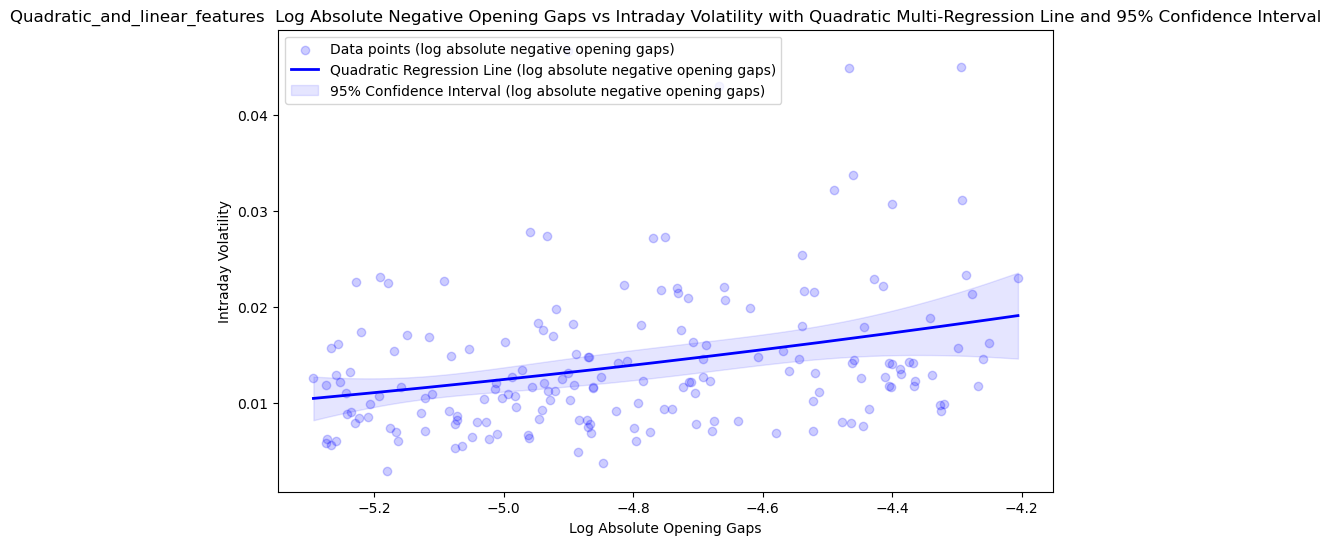

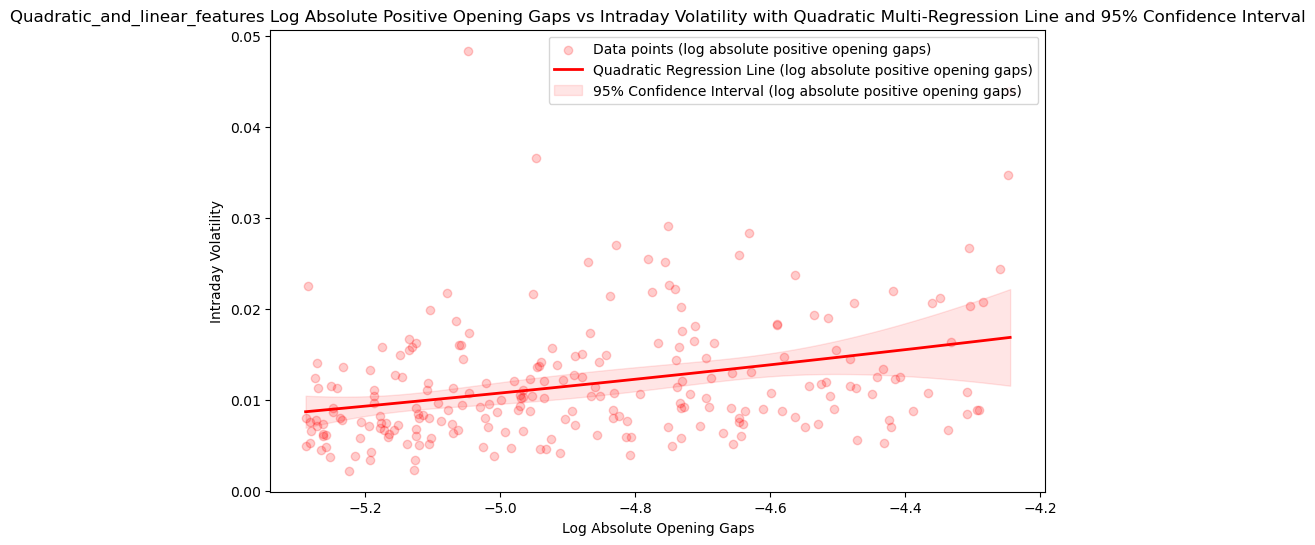

Negative Opening Gaps - Lagrange multiplier statistic: 3.651733994993274
Negative Opening Gaps - p-value: 0.1610779294108101
Positive Opening Gaps - Lagrange multiplier statistic: 3.5821875207368374
Positive Opening Gaps - p-value: 0.16677765508215955

Yes, the fact that your data is already log-transformed and you're still seeing significant heteroskedasticity in the Breusch-Pagan test results does indicate a 
serious issue. The purpose of log transformation is often to stabilize variance and address heteroskedasticity, so the persistence of heteroskedasticity even after
transformation suggests that the variance in your data is quite problematic.

Reducing the gap range to .5% to 1% fixes the heteroskedasticity issue.



In [16]:
# Filter the DataFrame based on the specified criteria and intraday volatility
filtered_data_below = data.loc[(data['opening_gaps'] > -0.015) & (data['opening_gaps'] < -0.005) & (data['Intraday_Volatility'] <= 0.05)].copy()
filtered_data_above = data.loc[(data['opening_gaps'] > 0.005) & (data['opening_gaps'] < 0.015) & (data['Intraday_Volatility'] <= 0.05)].copy()

# Apply log transformation using the absolute values
filtered_data_below['log_abs_opening_gaps'] = np.log(np.abs(filtered_data_below['opening_gaps']))
filtered_data_above['log_abs_opening_gaps'] = np.log(filtered_data_above['opening_gaps'])

# Add quadratic term for the first regression
filtered_data_below['log_abs_opening_gaps_squared'] = filtered_data_below['log_abs_opening_gaps'] ** 2

X_below = filtered_data_below[['log_abs_opening_gaps', 'log_abs_opening_gaps_squared']]
X_below = sm.add_constant(X_below)  # Adds a constant term to the predictor

y_below = filtered_data_below['Intraday_Volatility']

# Fit the model with RBSE
model_below = sm.OLS(y_below, X_below).fit(cov_type='HC3')

# Print the OLS results
print(model_below.summary())

# Predict values and get confidence intervals
predictions_below = model_below.get_prediction(X_below)
predictions_below_summary = predictions_below.summary_frame(alpha=0.05)
predicted_mean_below = predictions_below_summary['mean']
conf_int_below_lower = predictions_below_summary['mean_ci_lower']
conf_int_below_upper = predictions_below_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_below = np.argsort(filtered_data_below['log_abs_opening_gaps'])
sorted_log_abs_opening_gaps_below = filtered_data_below['log_abs_opening_gaps'].values[sorted_idx_below]
sorted_conf_int_below_lower = conf_int_below_lower.values[sorted_idx_below]
sorted_conf_int_below_upper = conf_int_below_upper.values[sorted_idx_below]
sorted_predicted_mean_below = predicted_mean_below.values[sorted_idx_below]

# Add quadratic term for the second regression
filtered_data_above['log_abs_opening_gaps_squared'] = filtered_data_above['log_abs_opening_gaps'] ** 2

X_above = filtered_data_above[['log_abs_opening_gaps', 'log_abs_opening_gaps_squared']]
X_above = sm.add_constant(X_above)  # Adds a constant term to the predictor

y_above = filtered_data_above['Intraday_Volatility']

# Fit the model with RBSE
model_above = sm.OLS(y_above, X_above).fit(cov_type='HC3')

# Print the OLS results
print(model_above.summary())

# Predict values and get confidence intervals
predictions_above = model_above.get_prediction(X_above)
predictions_above_summary = predictions_above.summary_frame(alpha=0.05)
predicted_mean_above = predictions_above_summary['mean']
conf_int_above_lower = predictions_above_summary['mean_ci_lower']
conf_int_above_upper = predictions_above_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_above = np.argsort(filtered_data_above['log_abs_opening_gaps'])
sorted_log_abs_opening_gaps_above = filtered_data_above['log_abs_opening_gaps'].values[sorted_idx_above]
sorted_conf_int_above_lower = conf_int_above_lower.values[sorted_idx_above]
sorted_conf_int_above_upper = conf_int_above_upper.values[sorted_idx_above]
sorted_predicted_mean_above = predicted_mean_above.values[sorted_idx_above]

# Create the scatter plot for negative opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the first regression
plt.scatter(filtered_data_below['log_abs_opening_gaps'], filtered_data_below['Intraday_Volatility'], 
                             color='blue', alpha=0.2, label='Data points (log absolute negative opening gaps)')

# Plot the quadratic regression line for the first regression
plt.plot(sorted_log_abs_opening_gaps_below, sorted_predicted_mean_below, color='blue', linewidth=2, label='Quadratic Regression Line (log absolute negative opening gaps)')

# Plot the confidence intervals for the first regression
plt.fill_between(sorted_log_abs_opening_gaps_below, sorted_conf_int_below_lower, sorted_conf_int_below_upper, color='blue', alpha=0.1, label='95% Confidence Interval (log absolute negative opening gaps)')

# Add labels and title
plt.xlabel('Log Absolute Opening Gaps')
plt.ylabel('Intraday Volatility')
plt.title('Quadratic_and_linear_features  Log Absolute Negative Opening Gaps vs Intraday Volatility with Quadratic Multi-Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Create the scatter plot for positive opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the second regression
plt.scatter(filtered_data_above['log_abs_opening_gaps'], filtered_data_above['Intraday_Volatility'], 
                             color='red', alpha=0.2, label='Data points (log absolute positive opening gaps)')

# Plot the quadratic regression line for the second regression
plt.plot(sorted_log_abs_opening_gaps_above, sorted_predicted_mean_above, color='red', linewidth=2, label='Quadratic Regression Line (log absolute positive opening gaps)')

# Plot the confidence intervals for the second regression
plt.fill_between(sorted_log_abs_opening_gaps_above, sorted_conf_int_above_lower, sorted_conf_int_above_upper, color='red', alpha=0.1, label='95% Confidence Interval (log absolute positive opening gaps)')

# Add labels and title
plt.xlabel('Log Absolute Opening Gaps')
plt.ylabel('Intraday Volatility')
plt.title('Quadratic_and_linear_features Log Absolute Positive Opening Gaps vs Intraday Volatility with Quadratic Multi-Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Perform the Breusch-Pagan test for the first regression
test_below = sms.het_breuschpagan(model_below.resid, model_below.model.exog)
print(f'Negative Opening Gaps - Lagrange multiplier statistic: {test_below[0]}')
print(f'Negative Opening Gaps - p-value: {test_below[1]}')

# Perform the Breusch-Pagan test for the second regression
test_above = sms.het_breuschpagan(model_above.resid, model_above.model.exog)
print(f'Positive Opening Gaps - Lagrange multiplier statistic: {test_above[0]}')
print(f'Positive Opening Gaps - p-value: {test_above[1]}')

print('''
Yes, the fact that your data is already log-transformed and you're still seeing significant heteroskedasticity in the Breusch-Pagan test results does indicate a 
serious issue. The purpose of log transformation is often to stabilize variance and address heteroskedasticity, so the persistence of heteroskedasticity even after
transformation suggests that the variance in your data is quite problematic.

Reducing the gap range to .5% to 1% fixes the heteroskedasticity issue.
''')


                             OLS Regression Results                            
Dep. Variable:     Intraday_Volatility   R-squared:                       0.096
Model:                             OLS   Adj. R-squared:                  0.091
Method:                  Least Squares   F-statistic:                     18.53
Date:                 Sat, 11 Jan 2025   Prob (F-statistic):           2.75e-05
Time:                         15:40:00   Log-Likelihood:                 636.96
No. Observations:                  181   AIC:                            -1270.
Df Residuals:                      179   BIC:                            -1264.
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const 

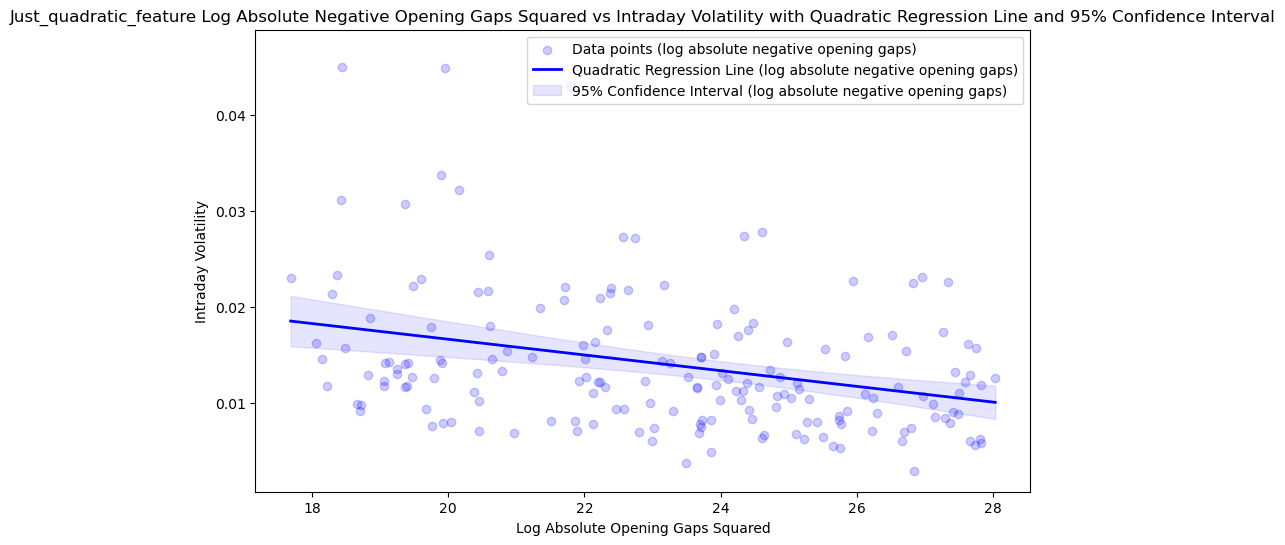

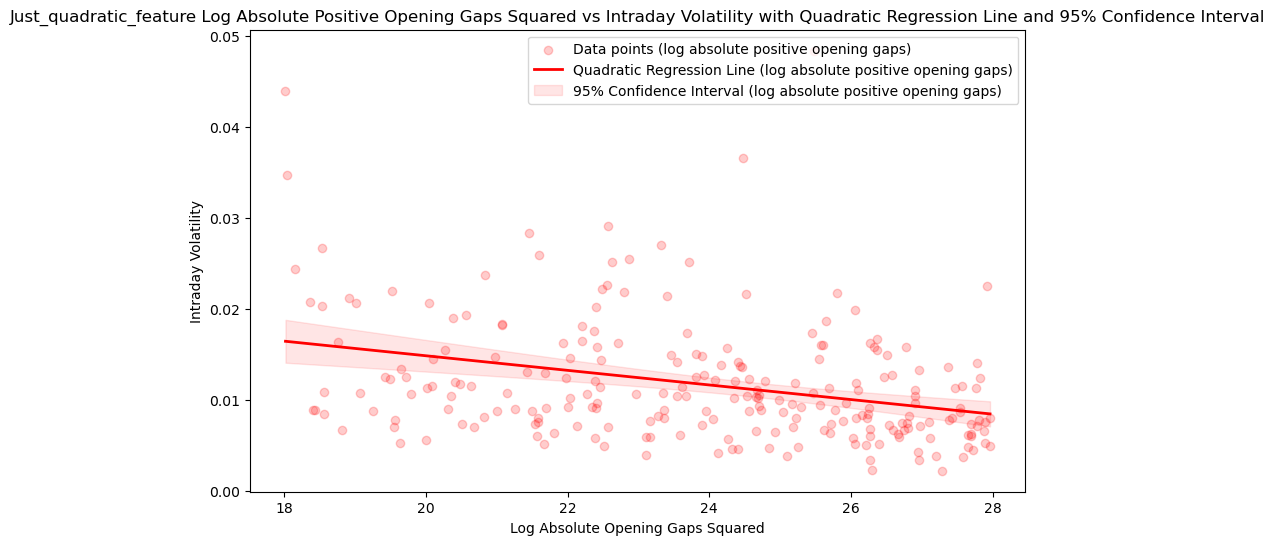

Negative Opening Gaps - Lagrange multiplier statistic: 3.5823971809519386
Negative Opening Gaps - p-value: 0.05839482764021057
Positive Opening Gaps - Lagrange multiplier statistic: 3.105509259857608
Positive Opening Gaps - p-value: 0.07802782484476846

the outperformacne of the qudaratic with linear feature scatterplot indicates that there is both a linear and quadratic relatinoship between the intraday volatiltiy 
and the opening gaps..




In [17]:
# Filter the DataFrame based on the specified criteria and intraday volatility
filtered_data_below = data.loc[(data['opening_gaps'] > -0.015) & (data['opening_gaps'] < -0.005) & (data['Intraday_Volatility'] <= 0.05)].copy()
filtered_data_above = data.loc[(data['opening_gaps'] > 0.005) & (data['opening_gaps'] < 0.015) & (data['Intraday_Volatility'] <= 0.05)].copy()

# Apply log transformation using the absolute values
filtered_data_below['log_abs_opening_gaps'] = np.log(np.abs(filtered_data_below['opening_gaps']))
filtered_data_above['log_abs_opening_gaps'] = np.log(filtered_data_above['opening_gaps'])

# Add quadratic term for the first regression
filtered_data_below['log_abs_opening_gaps_squared'] = filtered_data_below['log_abs_opening_gaps'] ** 2

X_below = filtered_data_below[['log_abs_opening_gaps_squared']]
X_below = sm.add_constant(X_below)  # Adds a constant term to the predictor

y_below = filtered_data_below['Intraday_Volatility']

# Fit the model with RBSE
model_below = sm.OLS(y_below, X_below).fit(cov_type='HC3')

# Print the OLS results
print(model_below.summary())

# Predict values and get confidence intervals
predictions_below = model_below.get_prediction(X_below)
predictions_below_summary = predictions_below.summary_frame(alpha=0.05)
predicted_mean_below = predictions_below_summary['mean']
conf_int_below_lower = predictions_below_summary['mean_ci_lower']
conf_int_below_upper = predictions_below_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_below = np.argsort(filtered_data_below['log_abs_opening_gaps_squared'])
sorted_log_abs_opening_gaps_below = filtered_data_below['log_abs_opening_gaps_squared'].values[sorted_idx_below]
sorted_conf_int_below_lower = conf_int_below_lower.values[sorted_idx_below]
sorted_conf_int_below_upper = conf_int_below_upper.values[sorted_idx_below]
sorted_predicted_mean_below = predicted_mean_below.values[sorted_idx_below]

# Add quadratic term for the second regression
filtered_data_above['log_abs_opening_gaps_squared'] = filtered_data_above['log_abs_opening_gaps'] ** 2

X_above = filtered_data_above[['log_abs_opening_gaps_squared']]
X_above = sm.add_constant(X_above)  # Adds a constant term to the predictor

y_above = filtered_data_above['Intraday_Volatility']

# Fit the model with RBSE
model_above = sm.OLS(y_above, X_above).fit(cov_type='HC3')

# Print the OLS results
print(model_above.summary())

# Predict values and get confidence intervals
predictions_above = model_above.get_prediction(X_above)
predictions_above_summary = predictions_above.summary_frame(alpha=0.05)
predicted_mean_above = predictions_above_summary['mean']
conf_int_above_lower = predictions_above_summary['mean_ci_lower']
conf_int_above_upper = predictions_above_summary['mean_ci_upper']

# Sort the values for fill_between
sorted_idx_above = np.argsort(filtered_data_above['log_abs_opening_gaps_squared'])
sorted_log_abs_opening_gaps_above = filtered_data_above['log_abs_opening_gaps_squared'].values[sorted_idx_above]
sorted_conf_int_above_lower = conf_int_above_lower.values[sorted_idx_above]
sorted_conf_int_above_upper = conf_int_above_upper.values[sorted_idx_above]
sorted_predicted_mean_above = predicted_mean_above.values[sorted_idx_above]

# Create the scatter plot for negative opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the first regression
plt.scatter(filtered_data_below['log_abs_opening_gaps_squared'], filtered_data_below['Intraday_Volatility'], 
                             color='blue', alpha=0.2, label='Data points (log absolute negative opening gaps)')

# Plot the quadratic regression line for the first regression
plt.plot(sorted_log_abs_opening_gaps_below, sorted_predicted_mean_below, color='blue', linewidth=2, label='Quadratic Regression Line (log absolute negative opening gaps)')

# Plot the confidence intervals for the first regression
plt.fill_between(sorted_log_abs_opening_gaps_below, sorted_conf_int_below_lower, sorted_conf_int_below_upper, color='blue', alpha=0.1, label='95% Confidence Interval (log absolute negative opening gaps)')

# Add labels and title
plt.xlabel('Log Absolute Opening Gaps Squared')
plt.ylabel('Intraday Volatility')
plt.title('Just_quadratic_feature Log Absolute Negative Opening Gaps Squared vs Intraday Volatility with Quadratic Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Create the scatter plot for positive opening gaps
plt.figure(figsize=(10, 6))

# Scatter plot for the second regression
plt.scatter(filtered_data_above['log_abs_opening_gaps_squared'], filtered_data_above['Intraday_Volatility'], 
                             color='red', alpha=0.2, label='Data points (log absolute positive opening gaps)')

# Plot the quadratic regression line for the second regression
plt.plot(sorted_log_abs_opening_gaps_above, sorted_predicted_mean_above, color='red', linewidth=2, label='Quadratic Regression Line (log absolute positive opening gaps)')

# Plot the confidence intervals for the second regression
plt.fill_between(sorted_log_abs_opening_gaps_above, sorted_conf_int_above_lower, sorted_conf_int_above_upper, color='red', alpha=0.1, label='95% Confidence Interval (log absolute positive opening gaps)')

# Add labels and title
plt.xlabel('Log Absolute Opening Gaps Squared')
plt.ylabel('Intraday Volatility')
plt.title('Just_quadratic_feature Log Absolute Positive Opening Gaps Squared vs Intraday Volatility with Quadratic Regression Line and 95% Confidence Interval')

# Add legend
plt.legend()

# Show and save the plot
plt.show()

# Perform the Breusch-Pagan test for the first regression
test_below = sms.het_breuschpagan(model_below.resid, model_below.model.exog)
print(f'Negative Opening Gaps - Lagrange multiplier statistic: {test_below[0]}')
print(f'Negative Opening Gaps - p-value: {test_below[1]}')

# Perform the Breusch-Pagan test for the second regression
test_above = sms.het_breuschpagan(model_above.resid, model_above.model.exog)
print(f'Positive Opening Gaps - Lagrange multiplier statistic: {test_above[0]}')
print(f'Positive Opening Gaps - p-value: {test_above[1]}')

print('''
the outperformacne of the qudaratic with linear feature scatterplot indicates that there is both a linear and quadratic relatinoship between the intraday volatiltiy 
and the opening gaps..

''')
